# 从 G5 到 G45：只改重叠因子 (r1, r2)，两点函数变脏、比值变平

固定一个共享能谱和固定的胶子矩阵元（参数取自 pz = 0, w = 0, HYP 8 的校准），只把插值算符的重叠因子从
G5 的 (r1, r2, rS) = (0.64, 0, 0.10) 连续变到 G45 的 (0, 1.04, 0.033)。

- 两点污染 = r1² + r2²：从 0.41 涨到 1.08（有效质量变脏）
- 比值线性污染 = (r1 M01 + r2 M02)/|M00|：从 8.4 降到 4.6（曲率变平）
- 第四个面板：蓝色虚线圆是两点污染的等高线，橙色直线是比值污染的等高线，G45 在更大的圆上却在更小的直线上

开关：`SLOW` 是否包含一个两点函数看不见的慢态；`SHOW_DATA` 是否叠画真实数据点（这里关掉）。

比值面板多了一条 tsep = 40 的黑色虚线：这是激发态都衰减完、真的收敛到 M00 的参考线；中点面板的横轴延长到 40，可以看到中点如何慢慢爬向 M00（灰线标出数据的最大 tsep = 14）。

In [8]:
%matplotlib inline
"""
demo_r1r2_G5_to_G45.py
======================
演示：固定一个共享能谱和固定的胶子矩阵元，只改变插值算符的重叠因子 (r1, r2)，从 G5 的取值走到 G45 的取值。
沿途看到：两点污染 r1^2 + r2^2 从 0.41 涨到 1.08（有效质量变脏），比值的线性污染 r1 M01 + r2 M02 却从大变小（曲率变平）。
参数尽量贴近 pz = 0, w = 0, HYP 8, 前向+后向平均, 799 组态的数据，真实数据点画在旁边做对照。

模型（精确谱和）：
    态 0 = pi 基态 E0 = 0.1413
    态 1: dE1 = 0.59 (G5 两点拟合看到的态),  态 2: dE2 = 0.94 (G45 两点拟合看到的态)
    态 S: dE_S = 0.20, 一个两点函数看不见的慢态 (r 很小)，可用 SLOW = False 关掉
    C2(t)         = 1 + r1^2 e^{-dE1 t} + r2^2 e^{-dE2 t} + rS^2 e^{-dES t}
    C3(tsep, tau) = M00 + sum_n r_n M0n [e^{-dE_n tau} + e^{-dE_n (tsep - tau)}] + sum_n r_n^2 Mnn e^{-dE_n tsep}
    R = C3 / C2
插值算符只通过 (r1, r2, rS) 进入；M0n, Mnn 是态的性质，两个算符共用。
    G5  : (r1, r2, rS) = (0.64, 0.00, 0.10)
    G45 : (r1, r2, rS) = (0.00, 1.04, 0.033)
胶子矩阵元按 tau >= 2 的数据做非关联最小二乘校准（仅供演示，M00 的数值不是物理结论）：
    SLOW = True : M00 = -0.083, M01 = 1.09, M02 = 0.37, M11 = -0.49, M22 = -0.65, M0S = -2.2, MSS = -1.9
    SLOW = False: M00 = -0.160, M01 = 0.41, M02 = 0.47, M11 = -0.41, M22 = -3.34  (拟合明显更差)

用法：
    命令行:   python demo_r1r2_G5_to_G45.py         -> r1r2_G5.png, r1r2_mid.png, r1r2_G45.png, r1r2.gif
    Jupyter:  from demo_r1r2_G5_to_G45 import animation_html, interactive
              animation_html()      # HTML5 动画 (不需要 ipywidgets)
              interactive()         # r1, r2, rS 滑块 + 播放键
"""
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# 中文字体：只保留系统里 matplotlib 真能找到的，避免每画一次就刷 "findfont: Font family ... not found"
import logging
import matplotlib.font_manager as fm
_available = {f.name for f in fm.fontManager.ttflist}
_cjk = [f for f in ("PingFang SC", "Songti SC", "STSong", "Hiragino Sans GB", "Noto Sans CJK SC",
                    "Arial Unicode MS", "SimHei", "Microsoft YaHei", "WenQuanYi Zen Hei") if f in _available]
plt.rcParams["font.family"] = _cjk + ["DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

SLOW = True          # 是否包含慢态 S
SHOW_DATA = False    # 是否把真实数据点画在模型旁边

# ----------------------------------------------------------------------------- 1. 真实数据 (pz0, w0, HYP8, fb, 799 cfg)
T_MEFF = np.arange(1, 15)
MEFF = {
    "G5":  (np.array([0.2559, 0.2002, 0.1725, 0.1581, 0.1506, 0.1468, 0.1445, 0.1428, 0.1424, 0.1415, 0.1415, 0.1413, 0.1412, 0.1409]), np.full(14, 0.0002)),
    "G45": (np.array([0.4731, 0.2572, 0.1814, 0.1557, 0.1466, 0.1438, 0.1425, 0.1413, 0.1412, 0.1408, 0.1412, 0.1413, 0.1413, 0.1411]),
            np.array([0.0005, 0.0004, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003])),
}
RATIO = {
    "G5": {
        4:  ([0.0649, 0.0387, 0.0149, 0.0152, 0.0287], [0.0203, 0.0182, 0.0162, 0.0157, 0.0158]),
        6:  ([0.0583, 0.0171, -0.0448, -0.0905, -0.0840, -0.0255, 0.0314], [0.0194, 0.0177, 0.0161, 0.0157, 0.0160, 0.0177, 0.0191]),
        8:  ([0.0690, 0.0194, -0.0522, -0.1156, -0.1477, -0.1379, -0.0932, -0.0252, 0.0388], [0.0187, 0.0173, 0.0159, 0.0156, 0.0161, 0.0183, 0.0203, 0.0188, 0.0167]),
        10: ([0.0740, 0.0232, -0.0494, -0.1163, -0.1599, -0.1767, -0.1777, -0.1575, -0.0961, 0.0019, 0.0784], [0.0184, 0.0172, 0.0160, 0.0158, 0.0164, 0.0192, 0.0216, 0.0195, 0.0169, 0.0158, 0.0156]),
        12: ([0.0769, 0.0289, -0.0438, -0.1141, -0.1648, -0.1910, -0.2010, -0.1962, -0.1714, -0.1180, -0.0444, 0.0298, 0.0762], [0.0185, 0.0175, 0.0163, 0.0160, 0.0169, 0.0204, 0.0233, 0.0205, 0.0171, 0.0161, 0.0163, 0.0174, 0.0182]),
        14: ([0.0882, 0.0370, -0.0382, -0.1078, -0.1577, -0.1836, -0.1927, -0.1888, -0.1748, -0.1489, -0.1171, -0.0812, -0.0340, 0.0241, 0.0625], [0.0189, 0.0179, 0.0167, 0.0165, 0.0176, 0.0209, 0.0235, 0.0207, 0.0175, 0.0169, 0.0175, 0.0184, 0.0191, 0.0185, 0.0178]),
    },
    "G45": {
        4:  ([-0.0060, -0.0553, -0.0893, -0.0637, -0.0095], [0.0148, 0.0140, 0.0132, 0.0128, 0.0130]),
        6:  ([0.0069, -0.0418, -0.0938, -0.1098, -0.0864, -0.0374, 0.0046], [0.0153, 0.0150, 0.0147, 0.0142, 0.0143, 0.0152, 0.0158]),
        8:  ([0.0079, -0.0482, -0.0981, -0.1136, -0.1128, -0.1123, -0.1026, -0.0625, -0.0107], [0.0163, 0.0163, 0.0160, 0.0154, 0.0152, 0.0168, 0.0182, 0.0172, 0.0159]),
        10: ([0.0076, -0.0477, -0.0960, -0.1126, -0.1167, -0.1201, -0.1257, -0.1282, -0.1098, -0.0612, -0.0138], [0.0174, 0.0176, 0.0175, 0.0169, 0.0171, 0.0197, 0.0219, 0.0200, 0.0176, 0.0165, 0.0166]),
        12: ([-0.0028, -0.0499, -0.0950, -0.1118, -0.1198, -0.1263, -0.1285, -0.1260, -0.1205, -0.1136, -0.0965, -0.0487, 0.0029], [0.0183, 0.0188, 0.0187, 0.0182, 0.0189, 0.0225, 0.0255, 0.0227, 0.0189, 0.0179, 0.0183, 0.0183, 0.0178]),
        14: ([-0.0038, -0.0520, -0.0993, -0.1164, -0.1261, -0.1346, -0.1340, -0.1279, -0.1236, -0.1226, -0.1215, -0.1067, -0.0775, -0.0403, -0.0106], [0.0197, 0.0200, 0.0197, 0.0190, 0.0196, 0.0233, 0.0261, 0.0234, 0.0199, 0.0190, 0.0196, 0.0204, 0.0208, 0.0200, 0.0195]),
    },
}
RATIO = {G: {ts: (np.array(m), np.array(e)) for ts, (m, e) in d.items()} for G, d in RATIO.items()}

# ----------------------------------------------------------------------------- 2. 谱模型
E0 = 0.1413
DE = np.array([0.59, 0.94, 0.20])                       # 态 1, 2, S 的能隙
R_G5 = np.array([0.64, 0.00, 0.10])                     # (r1, r2, rS)
R_G45 = np.array([0.00, 1.04, 0.033])
if SLOW:
    # 含慢态的校准 (chi2/ndof = 77/125，非关联)：慢态 M0S < 0 把两个算符的平台都压到 M00 之下
    M00 = -0.083
    M0 = np.array([1.09, 0.37, -2.2])                   # 跃迁矩阵元 M01, M02, M0S
    MNN = np.array([-0.49, -0.65, -1.9])                # 激发态对角元 M11, M22, MSS
else:
    # 不含慢态的校准 (chi2/ndof = 284/127，明显更差：描述不了 G5 中点在 tsep 8-12 的下滑和两个平台的差)
    M00 = -0.160
    M0 = np.array([0.41, 0.47, 0.0])
    MNN = np.array([-0.41, -3.34, 0.0])
    R_G5[2] = R_G45[2] = 0.0


def c2_model(r, t):
    t = np.asarray(t, float)[..., None]
    return 1.0 + np.sum(r ** 2 * np.exp(-DE * t), axis=-1)


def meff_model(r, t):
    return E0 + np.log(c2_model(r, t) / c2_model(r, np.asarray(t) + 1))


def ratio_model(r, tsep, tau):
    tsep = np.asarray(tsep, float)[..., None]; tau = np.asarray(tau, float)[..., None]
    c3 = M00 + np.sum(r * M0 * (np.exp(-DE * tau) + np.exp(-DE * (tsep - tau))), axis=-1) \
             + np.sum(r ** 2 * MNN * np.exp(-DE * tsep), axis=-1)
    return c3 / c2_model(r, tsep[..., 0])


def r_of(alpha):
    """alpha = 0 -> G5, alpha = 1 -> G45，重叠因子线性插值。"""
    return (1 - alpha) * R_G5 + alpha * R_G45


def contamination_2pt(r):
    """两点函数的激发态权重 r1^2 + r2^2 (+ rS^2)。"""
    return float(np.sum(r ** 2))


def contamination_ratio(r, tsep=10):
    """比值中点处激发态贡献 / |M00|，只算基态-激发态交叉项。"""
    return float(np.sum(2 * r * M0 * np.exp(-DE * tsep / 2)) / abs(M00))


# ----------------------------------------------------------------------------- 3. 画图
COL = {"G5": "#1f77b4", "G45": "#d62728"}
TSEP_SHOW = (6, 10, 14,16,18 ,40)                            # 40 是“真的收敛到 M00”的参考线（数据最大 tsep 为 14）
TSEP_COL = {6: "#2ca02c", 10: "#9467bd", 14: "#8c564b", 40: "black"}
TSEP_MID = np.arange(4, 41)


def make_figure():
    fig, axes = plt.subplots(1, 4, figsize=(20, 4.8), dpi=100, gridspec_kw=dict(width_ratios=[1, 1.15, 1, 1]))
    ax1, ax2, ax3, ax4 = axes
    art = {"data": []}                                   # data 里存 (artist, G) 以便按 alpha 调透明度
    # 左 1：两点有效质量
    for G in (("G5", "G45") if SHOW_DATA else ()):
        m, e = MEFF[G]
        eb = ax1.errorbar(T_MEFF, m, e, fmt="o", ms=4, color=COL[G], mfc=COL[G] if G == "G5" else "white", label=f"{G} 数据")
        art["data"].append((eb, G))
    art["meff"], = ax1.plot([], [], "k-", lw=2, label="模型 (r1, r2)")
    ax1.axhline(E0, color="gray", ls="--", lw=1, label=f"$E_0$ = {E0}")
    ax1.set_xlim(0.5, 14.5); ax1.set_ylim(0.136, 0.20)
    ax1.set_xlabel("$t$"); ax1.set_ylabel(r"$m_{\rm eff}(t)$"); ax1.set_title("两点有效质量")
    ax1.legend(fontsize=8, loc="upper right"); ax1.grid(alpha=0.3)
    # 左 2：R(tsep, tau)
    for ts in TSEP_SHOW:
        for G in (("G5", "G45") if SHOW_DATA and ts in RATIO["G5"] else ()):
            m, e = RATIO[G][ts]; tau = np.arange(ts + 1); x = tau - ts / 2
            inner = (tau >= 2) & (tau <= ts - 2)
            eb = ax2.errorbar(x[inner] + (0.12 if G == "G45" else 0), m[inner], e[inner], fmt="o", ms=4, color=TSEP_COL[ts],
                              mfc=TSEP_COL[ts] if G == "G5" else "white", capsize=2, lw=1)
            art["data"].append((eb, G))
        art[f"R_{ts}"], = ax2.plot([], [], "--" if ts >= 30 else "-", color=TSEP_COL[ts], lw=2,
                                   label=f"模型 tsep = {ts}" + ("  (收敛到 $M_{00}$)" if ts >= 30 else ""))
    if SHOW_DATA:
        ax2.plot([], [], "o", color="gray", label="G5 数据 (实心)"); ax2.plot([], [], "o", color="gray", mfc="white", label="G45 数据 (空心)")
    ax2.axhline(M00, color="gray", ls=":", lw=1)
    ax2.set_xlim(-6, 6); ax2.set_ylim(-0.25, 0.05)
    ax2.set_xlabel(r"$\tau - t_{\rm sep}/2$"); ax2.set_ylabel("$R = C_3/C_2$"); ax2.set_title("比值 R(tsep, τ)，参数取自 pz=0, w=0, HYP8" + (" (数据 τ ≤ 1 未画)" if SHOW_DATA else ""))
    ax2.legend(fontsize=8, loc="lower right", ncol=2); ax2.grid(alpha=0.3)
    # 左 3：中点 vs tsep
    for G in (("G5", "G45") if SHOW_DATA else ()):
        ts_list = sorted(RATIO[G]); mids = [RATIO[G][ts][0][ts // 2] for ts in ts_list]; errs = [RATIO[G][ts][1][ts // 2] for ts in ts_list]
        eb = ax3.errorbar(ts_list, mids, errs, fmt="o", ms=4, color=COL[G], mfc=COL[G] if G == "G5" else "white", label=f"{G} 数据")
        art["data"].append((eb, G))
    art["mid"], = ax3.plot([], [], "k-", lw=2, label="模型")
    ax3.axhline(M00, color="gray", ls=":", lw=1, label="模型的 $M_{00}$")
    ax3.axvline(14.5, color="gray", lw=0.8, alpha=0.5); ax3.text(15, 0.04, "数据最大 tsep = 14", fontsize=8, color="gray")
    ax3.set_xlim(3, 41); ax3.set_ylim(-0.25, 0.06)
    ax3.set_xlabel(r"$t_{\rm sep}$"); ax3.set_ylabel(r"$R(t_{\rm sep}, t_{\rm sep}/2)$"); ax3.set_title("中点 vs tsep")
    ax3.legend(fontsize=8, loc="upper right"); ax3.grid(alpha=0.3)
    # 右：(r1, r2) 平面，两点污染的等高线 (圆) 与比值污染的等高线 (直线)，以及 G5 -> G45 的路径
    r1g, r2g = np.meshgrid(np.linspace(0, 1.2, 121), np.linspace(0, 1.2, 121))
    two = r1g ** 2 + r2g ** 2
    lin = (2 * r1g * M0[0] * np.exp(-DE[0] * 5) + 2 * r2g * M0[1] * np.exp(-DE[1] * 5)) / abs(M00)
    cs1 = ax4.contour(r1g, r2g, two, levels=[0.1, 0.25, 0.41, 0.7, 1.08, 1.5], colors="tab:blue", linewidths=1, linestyles="--")
    cs2 = ax4.contour(r1g, r2g, lin, levels=[0.1, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0], colors="tab:orange", linewidths=1)
    ax4.clabel(cs1, fmt="%.2f", fontsize=7); ax4.clabel(cs2, fmt="%.2f", fontsize=7)
    path = np.array([r_of(a)[:2] for a in np.linspace(0, 1, 50)])
    ax4.plot(path[:, 0], path[:, 1], "k-", lw=1, alpha=0.5)
    ax4.plot(*R_G5[:2], "o", color=COL["G5"], ms=9, label="G5  (0.64, 0)")
    ax4.plot(*R_G45[:2], "o", color=COL["G45"], mfc="white", ms=9, mew=2, label="G45 (0, 1.04)")
    art["point"], = ax4.plot([], [], "k*", ms=16, label="当前 (r1, r2)")
    ax4.plot([], [], "--", color="tab:blue", label="两点污染 $r_1^2+r_2^2$"); ax4.plot([], [], "-", color="tab:orange", label="比值污染 (tsep=10 中点) / $|M_{00}|$")
    ax4.set_xlim(0, 1.2); ax4.set_ylim(0, 1.2); ax4.set_aspect("equal")
    ax4.set_xlabel("$r_1$ (态 1, ΔE = 0.59)"); ax4.set_ylabel("$r_2$ (态 2, ΔE = 0.94)"); ax4.set_title("重叠因子平面：圆 = 两点污染，直线 = 比值污染")
    ax4.legend(fontsize=7, loc="upper right"); ax4.grid(alpha=0.3)
    art["title"] = fig.suptitle("", fontsize=11, y=1.03)
    fig.tight_layout()
    return fig, art


def draw(art, alpha):
    r = r_of(alpha)
    tt = np.linspace(1, 14, 200)
    art["meff"].set_data(tt, meff_model(r, tt))
    for ts in TSEP_SHOW:
        tau = np.linspace(0, ts, 200)
        art[f"R_{ts}"].set_data(tau - ts / 2, ratio_model(r, np.full_like(tau, ts), tau))
    art["mid"].set_data(TSEP_MID, ratio_model(r, TSEP_MID, TSEP_MID / 2))
    art["point"].set_data([r[0]], [r[1]])
    for eb, G in art["data"]:                              # 数据点随 alpha 淡入淡出：alpha=0 突出 G5，alpha=1 突出 G45
        a = 0.25 + 0.75 * ((1 - alpha) if G == "G5" else alpha)
        for child in eb.get_children():
            child.set_alpha(a)
    curv = ratio_model(r, 10, 2) - ratio_model(r, 10, 5)
    art["title"].set_text(
        f"alpha = {alpha:.2f}   (r1, r2, rS) = ({r[0]:.2f}, {r[1]:.2f}, {r[2]:.3f})   |   两点污染 r1²+r2² = {contamination_2pt(r[:2]):.2f}"
        f"   |   比值线性污染 (r1 M01 + r2 M02)/|M00| = {(r[0]*M0[0] + r[1]*M0[1])/abs(M00):.2f}"
        f"   |   tsep=10 中点污染 = {contamination_ratio(r):.2f}   |   曲率 R(10,2)−R(10,5) = {curv:+.3f}")


def ease(u):
    return 0.5 * (1 - np.cos(np.pi * u))


# ----------------------------------------------------------------------------- 4. 运行方式
def animation(n_frames=60, interval=80):
    fig, art = make_figure()
    def update(i):
        draw(art, ease(i / (n_frames - 1)))
        return []
    return fig, FuncAnimation(fig, update, frames=n_frames, interval=interval, blit=False)


def animation_html(**kw):
    from IPython.display import HTML
    fig, anim = animation(**kw); plt.close(fig)
    return HTML(anim.to_jshtml())


def interactive():
    import ipywidgets as W
    from IPython.display import display
    fig, art = make_figure(); plt.close(fig)
    out = W.Output()
    s_alpha = W.FloatSlider(0.0, min=0, max=1, step=0.02, description="G5 → G45")
    s_r1 = W.FloatSlider(R_G5[0], min=0, max=1.2, step=0.02, description="r1")
    s_r2 = W.FloatSlider(R_G5[1], min=0, max=1.2, step=0.02, description="r2")
    s_rS = W.FloatSlider(R_G5[2], min=0, max=0.3, step=0.005, description="rS (慢态)")
    manual = W.Checkbox(False, description="手动 (r1, r2, rS)")
    play = W.Play(value=0, min=0, max=50, step=1, interval=100, description="播放")
    def on_play(ch): s_alpha.value = ease(ch["new"] / 50)
    play.observe(on_play, names="value")
    def redraw(alpha, r1, r2, rS, manual):
        if manual:
            r = np.array([r1, r2, rS]); a = 0.5
            # 手动模式：直接用滑块的 r，alpha 只用来控制数据点透明度
            global R_G5, R_G45
            saved = (R_G5.copy(), R_G45.copy()); R_G5[:] = r; R_G45[:] = r
            draw(art, a); R_G5[:], R_G45[:] = saved
        else:
            draw(art, alpha)
        with out:
            out.clear_output(wait=True); display(fig)
    ui = W.VBox([W.HBox([play, s_alpha, manual]), W.HBox([s_r1, s_r2, s_rS])])
    display(ui, W.interactive_output(redraw, dict(alpha=s_alpha, r1=s_r1, r2=s_r2, rS=s_rS, manual=manual)))

## 动画（HTML5 播放器，不需要 ipywidgets）

KeyError: 16

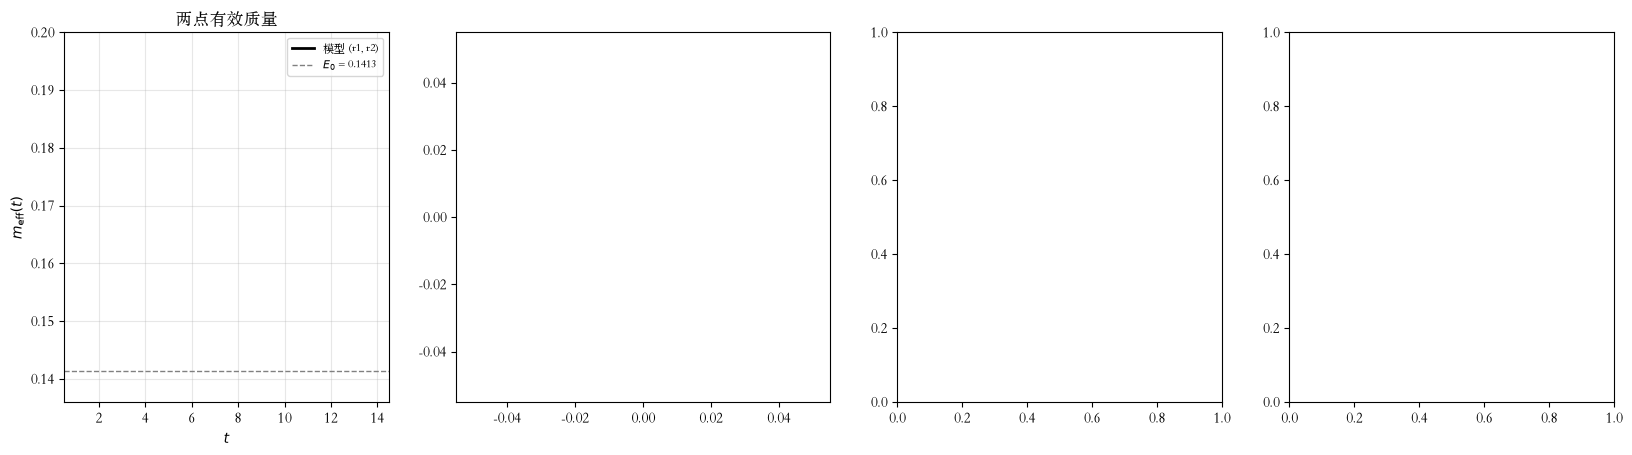

In [9]:
from IPython.display import HTML
fig, anim = animation(n_frames=60, interval=80)
plt.close(fig)                      # 只显示播放器，不额外显示最后一帧
HTML(anim.to_jshtml())

## 交互滑块（需要 ipywidgets）：播放键做 G5 → G45，勾选“手动”后可直接拨 r1, r2, rS

In [3]:
interactive()

Output()

## 保存 GIF

In [ ]:
fig, anim = animation(n_frames=50, interval=100)
anim.save("r1r2_nodata.gif", writer="pillow", fps=10, dpi=75)
plt.close(fig)
print("saved r1r2_nodata.gif")